# HamLib → Azure QDK vs. Qualtran: Side-by-Side Resource Estimation

This notebook walks through the complete resource-estimation pipeline step by step,
displaying every intermediate output. Both estimators receive the **same** canonical
Clifford+T circuit so differences in the final numbers reflect only the estimator
models, not the input.

## Pipeline overview

```
HamLib HDF5
  └─ Step 1 ─ Load Hamiltonian       → SparsePauliOp + metadata
       └─ Step 2 ─ Build evolution circuit  → QuantumCircuit (Trotter)
            └─ Step 3 ─ Transpile (Clifford+T)  → canonical circuit (shared)
                 ├─ Step 4 ─ Azure QDK estimate  → EstimationResult
                 └─ Step 5 ─ Qualtran estimate    → EstimationResult
                      └─ Step 6 ─ Compare         → side-by-side tables
```

All knobs live in `resourceEstimationPipeline/config.py`. Change parameters there
or override them in the **Configuration** cell below.

## Imports

In [1]:
import sys, os
import pathlib
# print(sys.executable)

# Locate the repo root: walk up from CWD until we find the directory that
# contains the resourceEstimationPipeline package.  Works regardless of
# whether Jupyter is launched from the repo root, the notebook directory,
# or anywhere else.
_search = pathlib.Path.cwd()
for _ in range(8):
    if (_search / "resourceEstimationPipeline").is_dir():
        REPO_ROOT = str(_search)
        break
    _search = _search.parent
else:
    REPO_ROOT = str(pathlib.Path.cwd())

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.4g}".format)

from IPython.display import display, Markdown

# Pipeline modules
from resourceEstimationPipeline.config import (
    PipelineConfig,
    HamlibConfig,
    EvolutionConfig,
    TranspileConfig,
    AzureConfig,
    QualtranConfig,
)
from resourceEstimationPipeline.loaders.hamlib_loader import load_hamiltonian
from resourceEstimationPipeline.circuit.evolution import build_evolution_circuit
from resourceEstimationPipeline.circuit.transpile import (
    transpile_to_clifford_t,
    circuit_stats,
    circuit_to_qasm,
)
from resourceEstimationPipeline.compare.metrics import compare
from resourceEstimationPipeline.compare.tables import (
    comparison_dataframe,
    differences_dataframe,
    missing_dataframe,
    explain_differences,
)

print(f"REPO_ROOT: {REPO_ROOT}")
print("Imports OK")

REPO_ROOT: /Users/kevinli/Documents/resourceEstimation
Imports OK


## Configuration

All pipeline parameters are consolidated here. Edit this cell to change the
Hamiltonian, evolution strategy, or estimator settings.

In [2]:
cfg = PipelineConfig(
    hamlib=HamlibConfig(
        hdf5_path=os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "heisenberg", "heis.hdf5"),
        key=None,         # None → use key_index below
        key_index=700,    # Pick a specific Hamiltonian by position in the file
    ),
    evolution=EvolutionConfig(
        evolution_time=1.0,
        synthesis_order=2,   # SuzukiTrotter order (1 or 2)
        synthesis_reps=10,   # number of Trotter repetitions
    ),
    transpile=TranspileConfig(
        optimization_level=1,
        seed_transpiler=42,      # deterministic output
    ),
    azure=AzureConfig(
        error_budget=0.01,
        error_rate=1e-3,
        gate_time_ns=50.0,
        measurement_time_ns=100.0,
        factory_type="Litinski19",   # 'Litinski19' or 'RoundBased'
    ),
    qualtran=QualtranConfig(
        data_d=17,
        phys_err=1e-3,
        cycle_time_us=1.0,
        rz_eps=1e-11,
        factory_type="Beverland",        # magic-state factory (used in custom cost-model path)
        use_beverland=True,
        use_gidney_fowler=False,
    ),
)

print(cfg)

PipelineConfig(hamlib=HamlibConfig(hdf5_path='/Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/heisenberg/heis.hdf5', key=None, key_index=700), evolution=EvolutionConfig(evolution_time=1.0, synthesis_order=2, synthesis_reps=10), transpile=TranspileConfig(basis_gates=['cx', 'rz', 'h', 's', 'sdg', 'x', 'y', 'z', 't', 'tdg'], optimization_level=1, seed_transpiler=42), azure=AzureConfig(error_budget=0.01, error_rate=0.001, gate_time_ns=50.0, measurement_time_ns=100.0, surface_code_distances=None, factory_type='Litinski19', slow_down_factors=[1.0], optimization_level=1, pareto_index=0), qualtran=QualtranConfig(data_d=17, data_d_sweep=None, phys_err=0.001, cycle_time_us=1.0, rz_eps=1e-11, factory_type='Beverland', use_gidney_fowler=False, use_beverland=True, pareto_index=0))


---
## Step 1 — Load Hamiltonian

Read a Hamiltonian from a HamLib HDF5 file and convert it to a Qiskit `SparsePauliOp`.

The loader uses `read_qiskit_hdf5` to decode the HamLib bytes directly into a
`SparsePauliOp`, and extracts metadata (`nqubits`, `one_norm`, `terms`) from HDF5
attributes.

In [3]:
ham_data = load_hamiltonian(cfg.hamlib)

print(f"HDF5 file : {ham_data.hdf5_path}")
print(f"Dataset key: {ham_data.key}")
print(f"Qubits    : {ham_data.nqubits}")
print(f"Terms     : {ham_data.n_terms}")
print(f"1-norm (λ): {ham_data.one_norm}")
print()
print("SparsePauliOp summary:")
print(f"  num_qubits = {ham_data.pauli_op.num_qubits}")
print(f"  size       = {len(ham_data.pauli_op)} terms")
print()
print("First 5 Pauli terms (label, coefficient):")
for label, coeff in zip(
    ham_data.pauli_op.paulis.to_labels()[:5],
    ham_data.pauli_op.coeffs[:5]
):
    print(f"  {label}  →  {coeff:.6g}")

HDF5 file : /Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/heisenberg/heis.hdf5
Dataset key: graph-1D-grid-pbc-qubitnodes_Lx-8_h-0
Qubits    : 8
Terms     : 24
1-norm (λ): 24.0

SparsePauliOp summary:
  num_qubits = 8
  size       = 24 terms

First 5 Pauli terms (label, coefficient):
  XXIIIIII  →  1+0j
  YYIIIIII  →  1+0j
  ZZIIIIII  →  1+0j
  XIIIIIIX  →  1+0j
  YIIIIIIY  →  1+0j


---
## Step 2 — Build Evolution Circuit

Build a Trotterized circuit for $e^{-iHt}$ using Qiskit's `PauliEvolutionGate`
with `SuzukiTrotter` synthesis.

The circuit contains a single high-level `PauliEvolutionGate`; transpilation in
Step 3 decomposes it into the canonical Clifford+T basis.

In [4]:
raw_circuit = build_evolution_circuit(ham_data, cfg.evolution)
raw_stats = circuit_stats(raw_circuit)

print(f"Evolution      : PauliEvolutionGate (SuzukiTrotter order={cfg.evolution.synthesis_order}, reps={cfg.evolution.synthesis_reps})")
print(f"Evolution time : t = {cfg.evolution.evolution_time}")
print()
print("Raw circuit statistics:")
print(f"  Qubits      : {raw_stats['num_qubits']}")
print(f"  Depth       : {raw_stats['depth']:,}")
print(f"  Total gates : {raw_stats['total_gates']:,}")
print(f"  Gate counts : {raw_stats['gate_counts']}")

Evolution      : PauliEvolutionGate (SuzukiTrotter order=2, reps=10)
Evolution time : t = 1.0

Raw circuit statistics:
  Qubits      : 8
  Depth       : 1
  Total gates : 1
  Gate counts : {'PauliEvolution': 1}


### Circuit diagram (first few qubits)

Draws the first 4 qubits and the first 40 moments of the raw circuit.

In [5]:
# Show a slice of the circuit for readability
n_show = min(4, raw_circuit.num_qubits)
try:
    from qiskit import QuantumCircuit
    # Slice: take first n_show qubits and first 40 operations
    ops_all = raw_circuit.data
    slice_ops = [op for op in ops_all if all(raw_circuit.find_bit(q).index < n_show for q in op.qubits)][:40]
    qc_slice = QuantumCircuit(n_show)
    for op in slice_ops:
        idx = [raw_circuit.find_bit(q).index for q in op.qubits]
        qc_slice.append(op.operation, idx)
    print(qc_slice.draw(fold=120))
except Exception as e:
    print(f"(diagram unavailable: {e})")
    print(raw_circuit)

     
q_0: 
     
q_1: 
     
q_2: 
     
q_3: 
     


---
## Step 3 — Deterministic Clifford+T Transpilation

Transpile the raw evolution circuit into the canonical Clifford+T basis.

**Why a shared circuit?** Both estimators are given the *same* canonical circuit so
any difference in their resource estimates reflects only their estimation models,
not the input.

Basis gates: `cx, rz, h, s, sdg, x, y, z, t, tdg`

The transpiler seed is fixed (`seed_transpiler=42`) so results are deterministic
across notebook re-runs.

In [6]:
ct_circuit = transpile_to_clifford_t(raw_circuit, cfg.transpile)
ct_stats = circuit_stats(ct_circuit)

print("Clifford+T circuit statistics:")
print(f"  Qubits         : {ct_stats['num_qubits']}")
print(f"  Depth          : {ct_stats['depth']:,}")
print(f"  Total gates    : {ct_stats['total_gates']:,}")
print(f"  T count        : {ct_stats['t_count']:,}")
print(f"  Clifford count : {ct_stats['clifford_count']:,}")
print(f"  Rz count       : {ct_stats['rz_count']:,}")
print(f"  Gate breakdown : {ct_stats['gate_counts']}")

Clifford+T circuit statistics:
  Qubits         : 8
  Depth          : 1,734
  Total gates    : 3,168
  T count        : 0
  Clifford count : 2,698
  Rz count       : 470
  Gate breakdown : {'h': 1136, 'cx': 922, 'rz': 470, 'sdg': 320, 's': 320}


### Circuit stats comparison: raw → Clifford+T

In [7]:
stats_df = pd.DataFrame([
    {
        "Stage": "Raw (pre-transpile)",
        "Qubits":      raw_stats["num_qubits"],
        "Depth":       raw_stats["depth"],
        "Total gates": raw_stats["total_gates"],
        "T count":     raw_stats["t_count"],
        "Clifford":    raw_stats["clifford_count"],
        "Rz":          raw_stats["rz_count"],
    },
    {
        "Stage": "Clifford+T (transpiled)",
        "Qubits":      ct_stats["num_qubits"],
        "Depth":       ct_stats["depth"],
        "Total gates": ct_stats["total_gates"],
        "T count":     ct_stats["t_count"],
        "Clifford":    ct_stats["clifford_count"],
        "Rz":          ct_stats["rz_count"],
    },
]).set_index("Stage")
display(stats_df)

,Qubits,Depth,Total gates,T count,Clifford,Rz
Stage,,,,,,
Raw (pre-transpile),8,1,1,0,0,0
Clifford+T (transpiled),8,1734,3168,0,2698,470


### OpenQASM 3 export (first 30 lines)

The circuit is exported to OpenQASM 3 and passed directly to the Azure QDK estimator.

In [8]:
qasm_source = circuit_to_qasm(ct_circuit)
lines = qasm_source.split("\n")
print(f"Total lines: {len(lines)}")
print("\n".join(lines[:30]))
if len(lines) > 30:
    print(f"  ... ({len(lines)} lines total)")

Total lines: 3172
OPENQASM 3.0;
include "stdgates.inc";
qubit[8] q;
h q[0];
h q[1];
h q[2];
h q[3];
h q[4];
h q[5];
h q[6];
h q[7];
cx q[6], q[7];
rz(0.1) q[7];
cx q[6], q[7];
h q[6];
sdg q[6];
h q[6];
h q[7];
sdg q[7];
h q[7];
cx q[6], q[7];
rz(0.1) q[7];
cx q[6], q[7];
h q[6];
s q[6];
h q[7];
s q[7];
cx q[6], q[7];
rz(0.1) q[7];
cx q[6], q[7];
  ... (3172 lines total)


---
## Step 4 — Azure QDK Resource Estimation

The Azure QDK Resource Estimator (`qdk.qre`) takes:
- An OpenQASM 3 circuit (exported above)
- A physical hardware model (`GateBased` with error rate + gate times)
- A QEC code (`SurfaceCode`) and magic-state factory (`Litinski19Factory`)
- A total error budget (`max_error`)

It sweeps code distances internally and returns a Pareto front of
(physical qubits, runtime) trade-offs.

In [9]:
azure_result = None
_azure_error = None

try:
    from resourceEstimationPipeline.estimators.azure import estimate as azure_estimate
    azure_result = azure_estimate(ct_circuit, cfg)
    print("Azure QDK estimation complete.")
    print(f"  Physical qubits : {azure_result.physical_qubits:,}")
    print(f"  Runtime         : {azure_result.runtime_seconds:.4f} s")
    print(f"  Logical error   : {azure_result.logical_error_rate:.3e}")
    if azure_result.t_per_rotation is not None:
        print(f"  T/rotation      : {azure_result.t_per_rotation}")
    if azure_result.factory_count:
        print(f"  Factory config  : {azure_result.factory_count}")
except ImportError as e:
    _azure_error = f"qdk not installed — {e}"
    print(f"⚠ Azure estimator unavailable: {_azure_error}")
    print("  Install with: pip install qdk")
except Exception as e:
    _azure_error = str(e)
    print(f"⚠ Azure estimation failed: {_azure_error}")

Azure QDK estimation complete.
  Physical qubits : 29,125
  Runtime         : 0.0207 s
  Logical error   : 7.349e-03
  T/rotation      : 14
  Factory config  : 5×T


### Azure assumptions

In [10]:
if azure_result is not None:
    print("Algorithm assumptions:")
    print(" ", azure_result.algorithm_assumptions)
    print()
    print("Architecture assumptions:")
    print(" ", azure_result.architecture_assumptions)
else:
    az = cfg.azure
    print("(Azure did not run — assumptions from config)")
    print(f"  error_rate={az.error_rate:.0e}, error_budget={az.error_budget}")
    print(f"  gate_time={az.gate_time_ns} ns, meas_time={az.measurement_time_ns} ns")
    print(f"  factory={az.factory_type}, QEC=SurfaceCode")

Algorithm assumptions:
  Clifford+T circuit; basis=['cx', 'rz', 'h', 's', 'sdg', 'x', 'y', 'z', 't', 'tdg']; PauliEvolutionGate SuzukiTrotter order=2 reps=10; t=1.0

Architecture assumptions:
  GateBased error_rate=0.001, gate_time=50.0 ns, meas_time=100.0 ns; SurfaceCode QEC; factory=Litinski19


---
## Step 5 — Qualtran Resource Estimation

The Qualtran estimator takes:
- The same canonical Clifford+T circuit, converted to a `CompositeBloq`
- A code distance `data_d` (instead of an error budget)
- A `PhysicalCostModel` (Gidney-Fowler CCZ2T factory by default)

It computes exact logical gate counts from the bloq graph, then maps them
to physical resources using the surface-code cost model.

In [11]:
qualtran_result = None
_qualtran_error = None

try:
    from resourceEstimationPipeline.estimators.qualtran import estimate as qt_estimate
    qualtran_result = qt_estimate(ct_circuit, cfg)
    print("Qualtran estimation complete.")
    print(f"  Physical qubits : {qualtran_result.physical_qubits:,}")
    print(f"  Runtime         : {qualtran_result.runtime_seconds:.4f} s")
    print(f"  Code distance   : {qualtran_result.code_distance}")
    print(f"  T count (total) : {qualtran_result.t_count:,}")
    print(f"  Clifford count  : {qualtran_result.clifford_count:,}")
    print(f"  Rotation count  : {qualtran_result.rotation_count:,}")
    print(f"  Logical qubits  : {qualtran_result.logical_qubits}")
    print(f"  Logical error   : {qualtran_result.logical_error_rate:.3e}")
except ImportError as e:
    _qualtran_error = f"qualtran not installed — {e}"
    print(f"⚠ Qualtran estimator unavailable: {_qualtran_error}")
    print("  Install with: pip install qualtran")
except Exception as e:
    _qualtran_error = str(e)
    print(f"⚠ Qualtran estimation failed: {_qualtran_error}")

Qualtran estimation complete.
  Physical qubits : 8,082
  Runtime         : 0.3164 s
  Code distance   : 17
  T count (total) : 51,230
  Clifford count  : 2,698
  Rotation count  : 470
  Logical qubits  : 8
  Logical error   : 1.054e-01


### Qualtran AlgorithmSummary (logical gate counts)

In [12]:
if qualtran_result is not None and "algo_summary" in qualtran_result.extra:
    asm = qualtran_result.extra["algo_summary"]
    asm_df = pd.DataFrame([asm]).T
    asm_df.columns = ["Count"]
    asm_df.index.name = "Metric"
    display(asm_df)
    print()
    print("T-count breakdown:")
    print(f"  T (exact gates)    : {asm['t_exact']:,}")
    print(f"  T (via Rz synth.)  : {asm['t_total'] - asm['t_exact']:,}")
    print(f"  T (total)          : {asm['t_total']:,}")
    print(f"  rz_eps             : {cfg.qualtran.rz_eps:.0e}")
else:
    print("(Qualtran did not run or algo_summary unavailable)")

,Count
Metric,
t_exact,0
t_total,51230
rotation_count,470
clifford_count,2698
toffoli_count,0
and_count,0
measurement,0
n_algo_qubits,8



T-count breakdown:
  T (exact gates)    : 0
  T (via Rz synth.)  : 51,230
  T (total)          : 51,230
  rz_eps             : 1e-11


### Qualtran assumptions

In [13]:
if qualtran_result is not None:
    print("Algorithm assumptions:")
    print(" ", qualtran_result.algorithm_assumptions)
    print()
    print("Architecture assumptions:")
    print(" ", qualtran_result.architecture_assumptions)
else:
    qt = cfg.qualtran
    print("(Qualtran did not run — assumptions from config)")
    print(f"  data_d={qt.data_d}, phys_err={qt.phys_err:.0e}")
    print(f"  cycle_time={qt.cycle_time_us} µs, factory={qt.factory_type}")

Algorithm assumptions:
  Clifford+T circuit; basis=['cx', 'rz', 'h', 's', 'sdg', 'x', 'y', 'z', 't', 'tdg']; rz_eps=1e-11; PauliEvolutionGate SuzukiTrotter order=2 reps=10; t=1.0

Architecture assumptions:
  Beverland factory; surface-code d=17; phys_err=1e-03; cycle_time=1.0 µs


---
## Step 6 — Side-by-Side Comparison

The comparison layer operates only on the public fields of `EstimationResult`.
It never reads estimator internals, so results remain comparable as new
estimators are added.

In [14]:
from resourceEstimationPipeline.compare.metrics import enrich_from_circuit
azure_result = enrich_from_circuit(azure_result, ct_circuit)
qualtran_result = enrich_from_circuit(qualtran_result, ct_circuit)
available_results = [r for r in [azure_result, qualtran_result] if r is not None]

if not available_results:
    print("No estimation results available — check estimator errors above.")
    report = None
else:
    report = compare(available_results)
    print(f"Estimators compared   : {report.estimator_names}")
    print(f"Shared metrics        : {len(report.shared_metrics)}")
    print(f"N/A in ≥1 estimator   : {len(report.missing_metrics)}")
    print(f"Numeric differences   : {len(report.differences)}")

Estimators compared   : ['Azure QDK (err_rate=1e-03, budget=0.01)', 'Qualtran (d=17, p=1e-03)']
Shared metrics        : 20
N/A in ≥1 estimator   : 13
Numeric differences   : 8


### Full comparison table

In [15]:
if report is not None:
    df = comparison_dataframe(report)
    display(df)
    n_shared = len(report.shared_metrics)
    n_missing = len(report.missing_metrics)
    n_total = len(report.metric_rows)
    display(Markdown(
        f"*{n_total} metrics total — "
        f"**{n_shared} shared** (both estimators report a value) | "
        f"**{n_missing} framework-specific** (N/A in ≥1 estimator) | "
        f"Ratio column shows '—' when values are non-numeric or unavailable.*"
    ))
else:
    print("(no report — run both estimators first)")

,Metric,"Azure QDK (err_rate=1e-03, budget=0.01)","Qualtran (d=17, p=1e-03)",Ratio (B/A)
0,Logical qubits,8,8,1.000×
1,Logical depth,"1,734","1,734",1.000×
2,Logical cycles,N/A,"316,404",—
3,T count,"6,580","51,230",7.786×
4,T depth,0,0,—
5,Clifford count,"2,698","2,698",1.000×
6,Rotation count,470,470,1.000×
7,Toffoli count,0,0,—
8,Measurement count,0,0,—
9,Physical qubits (total),"29,125","8,082",0.277×


*33 metrics total — **20 shared** (both estimators report a value) | **13 framework-specific** (N/A in ≥1 estimator) | Ratio column shows '—' when values are non-numeric or unavailable.*

### Derived comparison metrics

Secondary metrics computed from the primary fields above.
These provide normalized comparisons independent of circuit size.
A metric is N/A when one or both estimators are missing the required input fields.

In [16]:
# Derived metrics: computed from primary fields; N/A when required inputs are missing.
# Ratio is only shown when both estimators have valid values for the required inputs.
_DERIVED_KEYS = [
    "Physical qubits per logical qubit",
    "Factory qubit fraction",
    "Runtime per T gate (s)",
    "T gates per logical qubit",
    "Logical cycles per T gate",
    "Physical qubits per T state",
]

_DERIVED_NOTES = {
    "Physical qubits per logical qubit": "total physical / logical qubits",
    "Factory qubit fraction":            "factory qubits / total physical qubits",
    "Runtime per T gate (s)":            "runtime / T count  [amortised cost per T state]",
    "T gates per logical qubit":         "T count / logical qubits  [algorithm complexity density]",
    "Logical cycles per T gate":         "logical cycles / T count  [approx.; T-dominated schedule]",
    "Physical qubits per T state":       "factory qubits / T count  [amortised factory overhead]",
}

if report is not None:
    names = report.estimator_names
    derived_rows = []
    for key in _DERIVED_KEYS:
        mc = report.get_metric(key)
        if mc is None:
            continue
        row = {
            "Derived Metric": mc.metric,
            "Formula": _DERIVED_NOTES.get(mc.metric, ""),
        }
        for name in names:
            v = mc.values.get(name)
            if v is None:
                row[name] = "N/A"
            elif isinstance(v, float):
                row[name] = f"{v:.4g}"
            elif isinstance(v, int):
                row[name] = f"{v:,}"
            else:
                row[name] = str(v)
        row["Ratio (B/A)"] = f"{mc.ratio:.3f}×" if mc.ratio is not None else "—"
        derived_rows.append(row)

    if derived_rows:
        dm_df = pd.DataFrame(derived_rows).set_index("Derived Metric")
        display(dm_df)
    else:
        print("(no derived metrics available — primary fields missing)")
else:
    print("(no report)")

,Formula,"Azure QDK (err_rate=1e-03, budget=0.01)","Qualtran (d=17, p=1e-03)",Ratio (B/A)
Derived Metric,,,,
Physical qubits per logical qubit,total physical / logical qubits,3641,1010,0.277×
Factory qubit fraction,factory qubits / total physical qubits,0.7931,N/A,—
Runtime per T gate (s),runtime / T count [amortised cost per T state],3.142e-06,6.176e-06,1.966×
T gates per logical qubit,T count / logical qubits [algorithm complexity density],822.5,6404,7.786×
Logical cycles per T gate,logical cycles / T count [approx.; T-dominated schedule],N/A,6.176,—
Physical qubits per T state,factory qubits / T count [amortised factory overhead],3.511,N/A,—


### Parameter alignment

The table below shows the hardware assumptions each estimator makes.
Parameters with matching values (e.g. `physical_error_rate`, `code_distance`) give the
closest apples-to-apples comparison. Parameters marked N/A have no equivalent
in the other estimator's timing model.

In [17]:
# Parameter alignment table: estimator hardware assumptions side-by-side.
# Match these parameters when trying to get apples-to-apples comparisons.
# N/A means the estimator uses a different timing model (e.g. Azure uses gate_time_ns
# while Qualtran uses cycle_time_us; neither has a direct equivalent in the other).
_PARAM_KEYS = [
    "Physical error rate",
    "Code distance",
    "Cycle time (µs)",
    "Gate time (ns)",
    "Measurement time (ns)",
    "Factory type",
    "Factory config",
    "Rotation synthesis precision (ε)",
    "T gates per rotation",
    "Error budget",
]

if report is not None:
    names = report.estimator_names
    param_rows = []
    for key in _PARAM_KEYS:
        mc = report.get_metric(key)
        if mc is None:
            continue
        row = {"Parameter": mc.metric}
        for name in names:
            v = mc.values.get(name)
            if v is None:
                row[name] = "N/A"
            elif isinstance(v, float):
                row[name] = f"{v:.4g}"
            elif isinstance(v, int):
                row[name] = f"{v:,}"
            else:
                row[name] = str(v)
        param_rows.append(row)

    if param_rows:
        params_df = pd.DataFrame(param_rows).set_index("Parameter")
        display(params_df)
else:
    print("(no report)")

,"Azure QDK (err_rate=1e-03, budget=0.01)","Qualtran (d=17, p=1e-03)"
Parameter,,
Physical error rate,0.001,0.001
Code distance,N/A,17
Cycle time (µs),N/A,1
Gate time (ns),50,N/A
Measurement time (ns),100,N/A
Factory type,Litinski19,Beverland
Factory config,5×T,Beverland
Rotation synthesis precision (ε),N/A,1e-11
T gates per rotation,14,109


### Metrics that differ between estimators

In [18]:
if report is not None:
    diff_df = differences_dataframe(report)
    if diff_df.empty:
        print("No numeric differences found (estimators agree within 0.1%).")
    else:
        display(diff_df)
else:
    print("(no report)")

,Metric,"Azure QDK (err_rate=1e-03, budget=0.01)","Qualtran (d=17, p=1e-03)",Ratio (B/A)
0,T count,"6,580","51,230",7.786×
1,Physical qubits (total),"29,125","8,082",0.277×
2,Runtime (s),0.02067,0.3164,15.304×
3,Logical error rate,0.007349,0.1054,14.344×
4,T gates per rotation,14,109,7.786×
5,Physical qubits per logical qubit,3641,1010,0.277×
6,Runtime per T gate (s),3.142e-06,6.176e-06,1.966×
7,T gates per logical qubit,822.5,6404,7.786×


### Metrics not available in all estimators

In [19]:
if report is not None:
    display(missing_dataframe(report))
else:
    print("(no report)")

,Metric,"Azure QDK (err_rate=1e-03, budget=0.01)","Qualtran (d=17, p=1e-03)"
0,Logical cycles,N/A,available
1,Physical compute qubits,available,N/A
2,Physical factory qubits,available,N/A
3,Physical memory qubits,N/A,N/A
4,Error budget,available,N/A
5,Code distance,N/A,available
6,Rotation synthesis precision (ε),N/A,available
7,Cycle time (µs),N/A,available
8,Gate time (ns),available,N/A
9,Measurement time (ns),available,N/A


---
## Why do the estimators produce different results?

Both estimators receive the **same** canonical Clifford+T circuit, so any
differences reflect their resource estimation models, not the input.

In [20]:
if report is not None:
    print(explain_differences(report))
else:
    # Print without a report object (static explanation)
    from resourceEstimationPipeline.compare.tables import explain_differences as _exp
    from resourceEstimationPipeline.compare.metrics import ComparisonReport, MetricComparison
    dummy = ComparisonReport(results=[], metric_rows=[], differences=[], shared_metrics=[], missing_metrics=[])
    print(_exp(dummy))

WHY DO THE ESTIMATORS PRODUCE DIFFERENT RESULTS?

Both estimators receive the SAME canonical Clifford+T circuit, so any differences arise purely from the resource estimation models, not the input circuit.

Key model differences:

1. T-gate synthesis for arbitrary Rz rotations
   • Azure QDK: reports NUM_TS_PER_ROTATION (the actual synthesis count
     it uses internally for the given error budget).
   • Qualtran: counts raw Rz gates from the bloq graph; T synthesis cost
     is estimated post-hoc via the Solovay-Kitaev formula ~3·log₂(1/ε).
   → Expect T-count differences when rotation_count > 0.

2. Error budget vs. code distance
   • Azure QDK: takes max_error (total budget); sweeps code distance
     internally to find the smallest code that satisfies the budget.
   • Qualtran: takes code distance directly; logical error is computed
     from the code, not the other way around.
   → Comparing at the 'same' code distance is the closest apples-to-apples.

3. Magic-state factory models

---
## Appendix A — Qualtran Pareto sweep

If `cfg.qualtran.data_d_sweep` is set to a list of distances, the Qualtran
estimator sweeps all of them and picks the best solution at `pareto_index`.
This table shows all solutions from the last sweep.

In [21]:
if qualtran_result is not None and "all_pareto_rows" in qualtran_result.extra:
    rows = qualtran_result.extra["all_pareto_rows"]
    pareto_df = pd.DataFrame(rows)
    if not pareto_df.empty:
        display(pareto_df)
    else:
        print("(no Pareto rows)")
else:
    print("Qualtran did not run or Pareto sweep data unavailable.")
    print("To sweep distances, set cfg.qualtran.data_d_sweep = list(range(7, 30, 2))")

,data_d,physical_qubits,duration_hr,error
0,17,8082,8.789e-05,0.1054


---
## Appendix B — Azure Pareto front

The Azure QDK sweeps code distances internally and returns a Pareto front.
This table shows all solutions from that sweep.

In [22]:
if azure_result is not None and "all_pareto_solutions" in azure_result.extra:
    pareto = azure_result.extra["all_pareto_solutions"]
    if pareto:
        display(pd.DataFrame(pareto))
    else:
        print("(no Azure Pareto solutions)")
else:
    print("Azure did not run or Pareto data unavailable.")

,qubits,runtime,error
0,29125,0 days 00:00:00.020674500,0.007349


---
## Appendix C — Circuit gate-count breakdown

In [23]:
all_gates = set(raw_stats["gate_counts"].keys()) | set(ct_stats["gate_counts"].keys())
rows = []
for g in sorted(all_gates):
    rows.append({
        "Gate": g,
        "Raw circuit": raw_stats["gate_counts"].get(g, 0),
        "Clifford+T circuit": ct_stats["gate_counts"].get(g, 0),
    })
gate_df = pd.DataFrame(rows).set_index("Gate")
display(gate_df)

,Raw circuit,Clifford+T circuit
Gate,,
PauliEvolution,1,0
cx,0,922
h,0,1136
rz,0,470
s,0,320
sdg,0,320


---
## Appendix D — Run the full pipeline as a one-liner

The cells above walk through each step individually for visibility.
The same result can be obtained with a single `pipeline.run()` call:

In [24]:
# Uncomment to run the full pipeline:
# from pipeline import run
# result = run(cfg, run_azure=True, run_qualtran=True)
# result.print_summary()

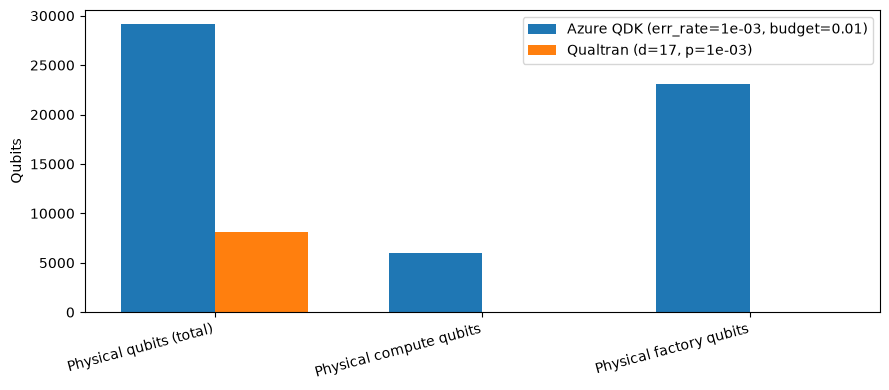

In [25]:
import matplotlib.pyplot as plt
import numpy as np

names = report.estimator_names
metrics = ["Physical qubits (total)", "Physical compute qubits", "Physical factory qubits"]

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(metrics))
width = 0.35

for i, name in enumerate(names):
    vals = [report.get_metric(m).values.get(name) or 0 for m in metrics]
    ax.bar(x + i * width, vals, width, label=name)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics, rotation=15, ha="right")
ax.set_ylabel("Qubits")
ax.legend()
plt.tight_layout()

{'num_qubits': 8, 'depth': 1734, 't_depth': 0, 'total_gates': 3168, 'gate_counts': {'h': 1136, 'cx': 922, 'rz': 470, 'sdg': 320, 's': 320}, 't_count': 0, 'clifford_count': 2698, 'rz_count': 470}
['T count', 'Clifford count', 'Rotation count (arb. Rz)', 'Toffoli count']


AttributeError: 'NoneType' object has no attribute 'values'

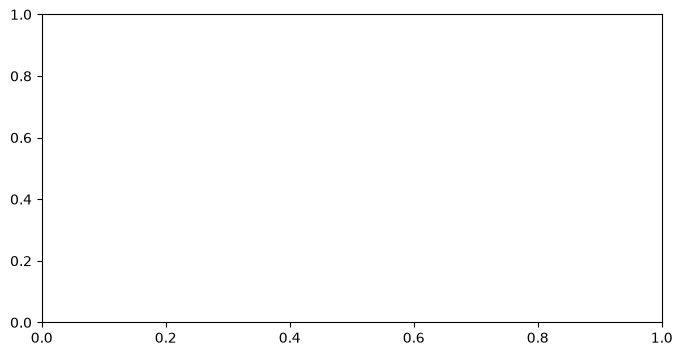

In [27]:
gate_metrics = ["T count", "Clifford count", "Rotation count (arb. Rz)", "Toffoli count"]
from resourceEstimationPipeline.circuit.transpile import circuit_stats
print(circuit_stats(ct_circuit))
fig, ax = plt.subplots(figsize=(8, 4))
print(gate_metrics)
for i, name in enumerate(names):
    vals = [report.get_metric(m).values.get(name) or 0 for m in gate_metrics]
    ax.bar(x + i * width, vals, width, label=name)

ax.set_yscale("log")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(gate_metrics, rotation=15, ha="right")
ax.set_ylabel("Count (log scale)")
ax.legend()
plt.tight_layout()

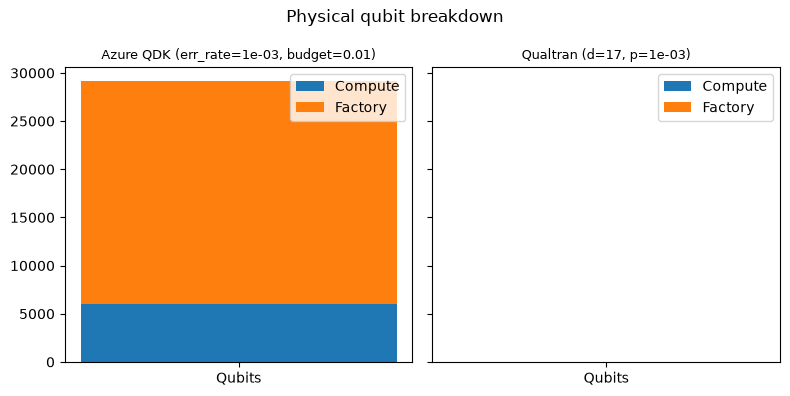

In [ ]:
fig, axes = plt.subplots(1, len(names), figsize=(8, 4), sharey=True)

for ax, name in zip(axes, names):
    compute = report.get_metric("Physical compute qubits").values.get(name) or 0
    factory = report.get_metric("Physical factory qubits").values.get(name) or 0
    ax.bar(["Qubits"], [compute], label="Compute")
    ax.bar(["Qubits"], [factory], bottom=[compute], label="Factory")
    ax.set_title(name, fontsize=9)
    ax.legend()
plt.suptitle("Physical qubit breakdown")
plt.tight_layout()

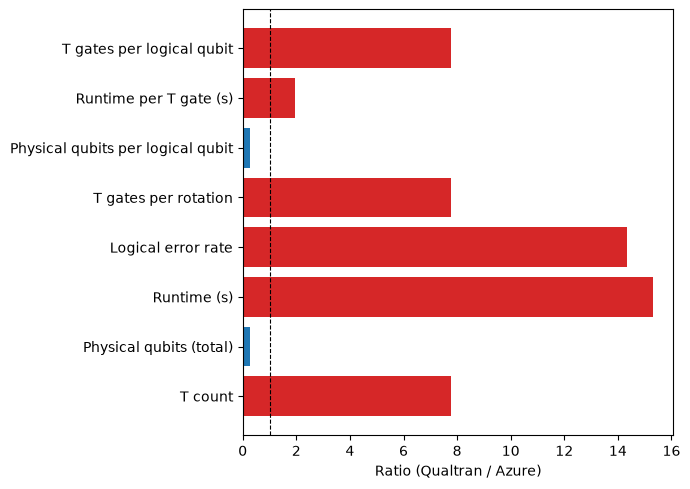

In [ ]:
diffs = [(m.metric, m.ratio) for m in report.differences if m.ratio is not None]
labels, ratios = zip(*diffs)

fig, ax = plt.subplots(figsize=(7, len(labels) * 0.5 + 1))
colors = ["tab:red" if r > 1 else "tab:blue" for r in ratios]
ax.barh(labels, ratios, color=colors)
ax.axvline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Ratio (Qualtran / Azure)")
plt.tight_layout()